# Poisson Regression

In this notebook we will:
- Learn the Poisson regression model
- Show how you can interpret Poisson regression output

Poisson Regression is used when the target variable is in ${0,1,2,\dots}$ and represents a count of some number of events occurring in a given unit of time (or space).

Before we can discuss Poisson Regression we first need to understand the Poisson distributed random variables. 

### Poisson Distribution

The **Poisson distribution** models the number of events occurring in a fixed interval of time, space, or opportunity, when events happen independently at a constant average rate.  

- **Formula:**  
  For a nonnegative integer $y = 0, 1, 2, \dots$, the probability is  
  $$
  \Pr(Y = y) = \frac{\mu^y e^{-\mu}}{y!},
  $$  
  where $\mu > 0$ is both the mean and the variance.

- **Key properties:**  
  - **Mean:** $\mathbb{E}[Y] = \mu$
  - **Variance:** $\operatorname{Var}(Y) = \mu$  
  - The distribution is skewed for small $\mu$, and becomes more symmetric as $\mu$ grows.  

- **Interpretation:**  
  - $Y$ counts how many times an event happens.  
  - $\mu$ is the expected number of events in the interval.  
  - Example: number of emails received in an hour, number of accidents at an intersection in a day, number of awards a student earns in a year.

We will give a derivation of the PMF in Math Hour from the assumption that events occur independently in time at a constant rate $\mu$.

Please see https://www.desmos.com/calculator/06a5ca1d4c for a geometric representation of the Poisson distribution!

### Explaining the model

Poisson regression is used for **count data** $(0, 1, 2, \dots)$.  

- The counts are assumed to follow a **Poisson distribution**:  

  $$
  Y \sim \text{Poisson}(\mu)
  $$  

  so that  
  $$
  \mathbb{E}[Y \mid X] = \mu, \quad \operatorname{Var}(Y \mid X) = \mu.
  $$

- The expected count is linked to predictors with a **log link**:  
  $$
  \log(\mu) = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p.
  $$

- Interpretation: a one-unit increase in predictor $x_j$ multiplies the expected count by $e^{\beta_j}$.

Think of it like this: each predictor **scales the expected number of events** instead of adding to it.  

**Example:** If the math score coefficient is 0.07, then  
$$
e^{0.07} \approx 1.07
$$  

so each extra point on the math test multiplies the expected number of awards by about **1.07** ($ \approx 7\%$ more awards).


Please see https://www.desmos.com/3d/28c15d4bb9 for a geometric representation of Poisson regression!

One common question people have is: why not just fit OLS on $(x, \log y)$ for counts?

- **Zeros problem.** Many observations have $y=0$ and $\log 0$ is undefined. Ad hoc fixes (e.g., $\log(y+1)$) distort estimates.
- **Wrong target.** OLS learns $\mathbb{E}[\log Y\mid x]$, but we want $\log \mathbb{E}[Y\mid x]$. By Jensen’s inequality, $\mathbb{E}[\log Y]\ \le\ \log \mathbb{E}[Y]$
- **Invalid predictions.** Back-transformed OLS can imply negative or non-integer expectations.
- **Inference mismatch.** OLS assumes Gaussian errors on $\log Y$. Poisson GLM maximizes the correct count likelihood.

#### Example:  Predicting number of awards from program type and math scores

The following example is adapted from https://stats.oarc.ucla.edu/r/dae/poisson-regression/

In this example, num_awards is the outcome variable and indicates the number of awards earned by students at a high school in a year, math is a continuous predictor variable and represents students’ scores on their math final exam, and prog is a categorical predictor variable with three levels indicating the type of program in which the students were enrolled. It is coded as 1 = “General”, 2 = “Academic” and 3 = “Vocational”. Let’s start with loading the data and looking at some descriptive statistics.

In [ ]:
import pandas as pd
df = pd.read_csv("https://stats.idre.ucla.edu/stat/data/poisson_sim.csv")

In [7]:
df

,id,num_awards,prog,math
0,45,0,3,41
1,108,0,1,41
2,15,0,3,44
3,67,0,3,42
4,153,0,3,40
...,...,...,...,...
195,100,2,2,71
196,143,2,3,75
197,68,1,2,71
198,57,0,2,72


We will fit the model:

$$
\log(\mu)
= \beta_0
+ \beta_1\mathbf{1}_{\text{prog}=2}
+ \beta_2\mathbf{1}_{\text{prog}=3}
+ \beta_3\text{math},
$$

where 
$$
Y \sim \text{Poisson}(\mu)
$$

and
$$
\mu=\mathbb{E}[\text{num\_awards}\mid \text{prog},\,\text{math}]
$$

In [19]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import PoissonRegressor

# Outcome
y = df["num_awards"]

# Predictors: math (continuous), prog (categorical)
X = df[["math", "prog"]]

# One-hot encode the categorical predictor 'prog'
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), ["prog"]),  # drop first to avoid collinearity
        ("num", "passthrough", ["math"])
    ]
)

# Build a pipeline with preprocessing + Poisson regression
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", PoissonRegressor(alpha=0, max_iter=1000))  # alpha=0 = no regularization
])

# Fit the model
model.fit(X, y)

# Coefficients
reg = model.named_steps["regressor"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
for name, coef in zip(feature_names, reg.coef_):
    print(f"{name}: {coef:.4f}")

print("Intercept:", reg.intercept_)


cat__prog_2: 1.0839
cat__prog_3: 0.3698
num__math: 0.0702
Intercept: -5.247119295242059


### Coefficient interpretation

Model:
$$
\log(\mu)
= -5.2471
+ 1.0839\,\mathbf{1}_{\text{prog}=2}
+ 0.3698\,\mathbf{1}_{\text{prog}=3}
+ 0.0702\,\text{math},
$$
where $\mu=\mathbb{E}[\text{num\_awards}\mid \text{prog},\,\text{math}]$.

- **Intercept $-5.2471$**: baseline log expected count for $\text{prog}=1$ and $\text{math}=0$.
- **$\text{prog}=2$ coefficient $1.0839$**: holding $\text{math}$ fixed, expected awards are multiplied by $e^{1.0839}\approx 2.95$ ($195\%$ increase) vs $\text{prog}=1$.
- **$\text{prog}=3$ coefficient $0.3698$**: holding $\text{math}$ fixed, expected awards are multiplied by $e^{0.3698}\approx 1.45$ ($45\%$ increase) vs $\text{prog}=1$.
- **$\text{math}$ coefficient $0.0702$**: each 1-point increase in $\text{math}$ multiplies the expected awards by $e^{0.0702}\approx 1.073$ ($7.3\%$ increase), holding $\text{prog}$ fixed.


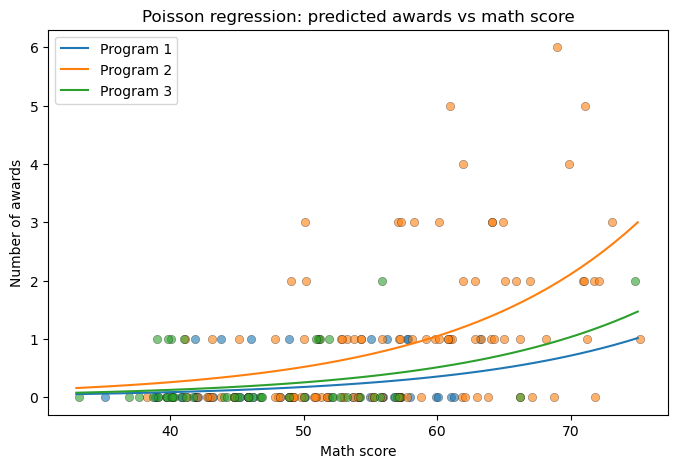

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Grid of math scores
math_range = np.linspace(df["math"].min(), df["math"].max(), 50)

# Prediction curves
prog_labels = [1, 2, 3]
colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}
predictions = {}

plt.figure(figsize=(8, 5))

# Plot predictions
for prog in prog_labels:
    X_pred = pd.DataFrame({
        "math": math_range,
        "prog": prog
    })
    mu = model.predict(X_pred)
    predictions[prog] = mu
    plt.plot(math_range, mu, color=colors[prog], label=f"Program {prog}")

# Plot raw data points, jittered slightly on x to reduce overplotting
for prog in prog_labels:
    subset = df[df["prog"] == prog]
    plt.scatter(
        subset["math"] + np.random.uniform(-0.3, 0.3, size=len(subset)),  # jitter
        subset["num_awards"],
        alpha=0.6,
        color=colors[prog],
        edgecolor="k",
        linewidth=0.3
    )

plt.xlabel("Math score")
plt.ylabel("Number of awards")
plt.title("Poisson regression: predicted awards vs math score")
plt.legend()
plt.show()
